In [1]:

import productomator.lab as prolab

In [2]:
rep = prolab.Reporter()

start time: 2026-09-01 12:36:16.588391


In [3]:
rep.warnings_increment

<bound method Reporter.warnings_increment of <productomator.lab.Reporter object at 0x16a36a660>>

# Info

When mfrsr shadowbands are not well aligned the direct normal shows a sawtooth pattern during clearsky conditions. This is because the shadowband moves only every 2 minutes or so. If the shadowband is missaligned, some sunlight makes it passed the band onto the diffuser. There are 6 measurments before the shadoband is adjusted again. During that time the amount of sunlight reaching the diffusor gets more or less, resulting in a sawtooth pattern. 

atmPy has a function that is designed to detect such missalignment, which is discussed here.

# Imports 
(probably not all neaded anymore)

In [4]:
import atmPy.radiation.retrievals.spectral_irradiance as atmspec

In [5]:
import scipy as sp

import matplotlib.colors as mcolors

import numpy as np
import xarray as xr
from scipy.stats import theilslopes

In [6]:
reload(atmspec)
reload(atmspec.atmlangcalib)

<module 'atmPy.radiation.retrievals.langley_calibration' from '/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/langley_calibration.py'>

# Load some data

In [7]:
ds = xr.open_dataset('/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosine_corrected/v0.2/2026/inl_mfrsr_cosinecorrected_20260830.nc')

## Detection algorithm in atmPy

In [8]:
import atmPy.radiation.instrumentation.mfrsr_tools as atmmt

In [9]:
reload(atmmt)

<module 'atmPy.radiation.instrumentation.mfrsr_tools' from '/Users/htelg/prog/atm-py/atmPy/radiation/instrumentation/mfrsr_tools.py'>

In [10]:
out = atmmt.check_shadowband_misalignment(ds)

In [11]:
out['detected']

True

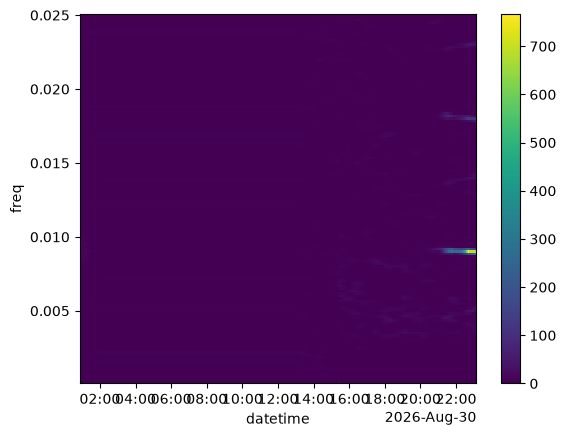

In [12]:
out['cleaned_powerspectrum_ts'].plot(x = 'datetime')

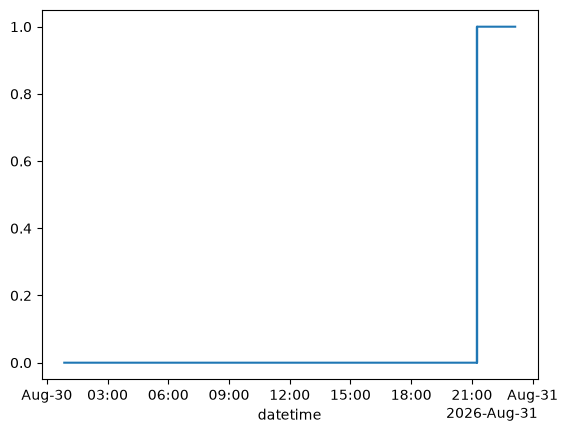

In [13]:
out['detected_ts'].plot()

## visualize

In [14]:
ds = ds.drop_vars(['solar_azimuth_angle', 'solar_zenith_angle']) # we will need to recalculate to get more solar positions anyway.

In [15]:
si = atmspec.CombinedGlobalDiffuseDirect(ds.copy())

In [16]:
sir = si.direct_normal_irradiation

In [17]:
sir.sun_position

<xarray.Dataset> Size: 346kB
Dimensions:              (datetime: 4320)
Coordinates:
  * datetime             (datetime) datetime64[ns] 35kB 2026-08-30 ... 2026-0...
Data variables:
    zenith               (datetime) float64 35kB 1.17 1.171 ... 1.173 1.174
    zenith_geometric     (datetime) float64 35kB 1.171 1.172 ... 1.174 1.175
    elevation_geometric  (datetime) float64 35kB 0.4001 0.3991 ... 0.3969 0.3959
    elevation            (datetime) float64 35kB 0.4007 0.3996 ... 0.3975 0.3964
    azimuth              (datetime) float64 35kB 4.545 4.546 ... 4.539 4.54
    equation_of_time     (datetime) float64 35kB -0.7869 -0.7868 ... -0.4778
    airmass              (datetime) float64 35kB 2.55 2.557 2.563 ... 2.57 2.576
    airmass_absolute     (datetime) float64 35kB 2.129 2.134 ... 2.145 2.151
    sun_earth_distance   (datetime) float64 35kB 1.01 1.01 1.01 ... 1.01 1.01
Attributes: (12/28)
    instrument:                        mfrsr
    start_time:                        2026-08-29 22:28:40
    avg_period:                        20
    sample_rate:                       20
    logger_id:                         $BF4F
    head_id:                           $97A4
    ...                                ...
    clalibration_cosine:               True
    shadowband_misalignment_detected:  True
    processing_class:                  surfradpy.products.mfrsr_cosinecorrect...
    calibration_file_cosine:           /nfs/grad/Calibration_facilities/cucf/...
    calibration_file_spectral:         /nfs/grad/Calibration_facilities/cucf/...
    version:                           0.2

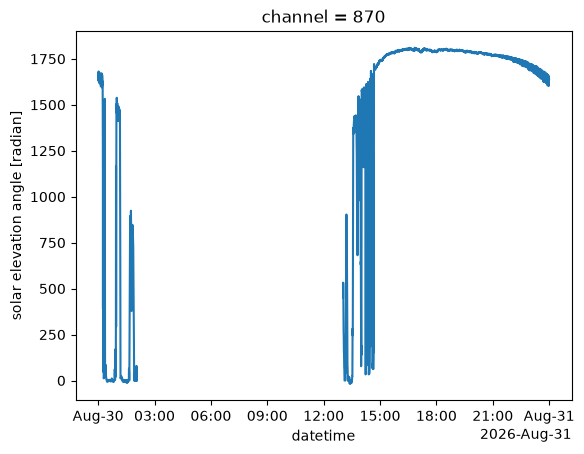

In [18]:
sir.dataset.direct_normal.sel(channel = 870).plot()

In [19]:
ds_pm = sir.dataset.where(np.logical_and(sir.sun_position.airmass < 6, sir.sun_position.airmass >2)).where(sir.sun_position.azimuth > np.deg2rad(180))

In [20]:
ds_am = sir.dataset.where(np.logical_and(sir.sun_position.airmass < 6, sir.sun_position.airmass >2)).where(sir.sun_position.azimuth < np.deg2rad(180))

In [24]:
%matplotlib widget

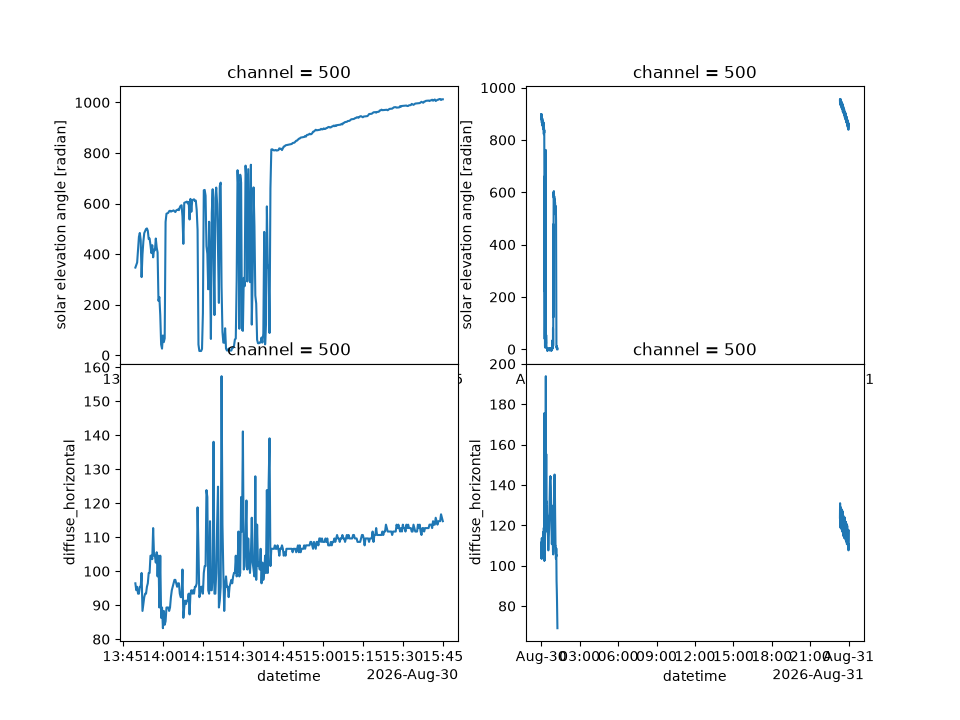

In [25]:
wl = 500
f,aa = plt.subplots(2,2, gridspec_kw={'hspace':0})
f.set_figheight(f.get_figheight() * 1.5)
f.set_figwidth(f.get_figwidth() * 1.5)

a = aa[0,0]
# sir.dataset.direct_normal.sel(channel = wl).plot()
ds_am.direct_normal.sel(channel = wl).plot(ax = a)

a = aa[0,1]
# sir.dataset.direct_normal.sel(channel = wl).plot()
ds_pm.direct_normal.sel(channel = wl).plot(ax = a)

a = aa[1,0]
# sir.dataset.direct_normal.sel(channel = wl).plot()
ds_am.diffuse_horizontal.sel(channel = wl).plot(ax = a)

a = aa[1,1]
ds_pm.diffuse_horizontal.sel(channel = wl).plot(ax = a)

In [26]:
wl = 870
f,aa = plt.subplots(2,2, gridspec_kw={'hspace':0})
f.set_figheight(f.get_figheight() * 1.5)
f.set_figwidth(f.get_figwidth() * 1.5)

a = aa[0,0]
# sir.dataset.direct_normal.sel(channel = wl).plot()
ds_am.direct_normal.sel(channel = wl).plot(ax = a)

a = aa[0,1]
# sir.dataset.direct_normal.sel(channel = wl).plot()
ds_pm.direct_normal.sel(channel = wl).plot(ax = a)

a = aa[1,0]
# sir.dataset.direct_normal.sel(channel = wl).plot()
ds_am.diffuse_horizontal.sel(channel = wl).plot(ax = a)

a = aa[1,1]
ds_pm.diffuse_horizontal.sel(channel = wl).plot(ax = a)

aaf = aa.flatten()
for a in aaf[[0,1]]:
    a.set_ylabel('direct normal [mV]')

for a in aaf[[1,3]]:
    a.set_ylabel('')

aaf[0].set_title('morning')
aaf[1].set_title('evening')

Text(0.5, 1.0, 'evening')

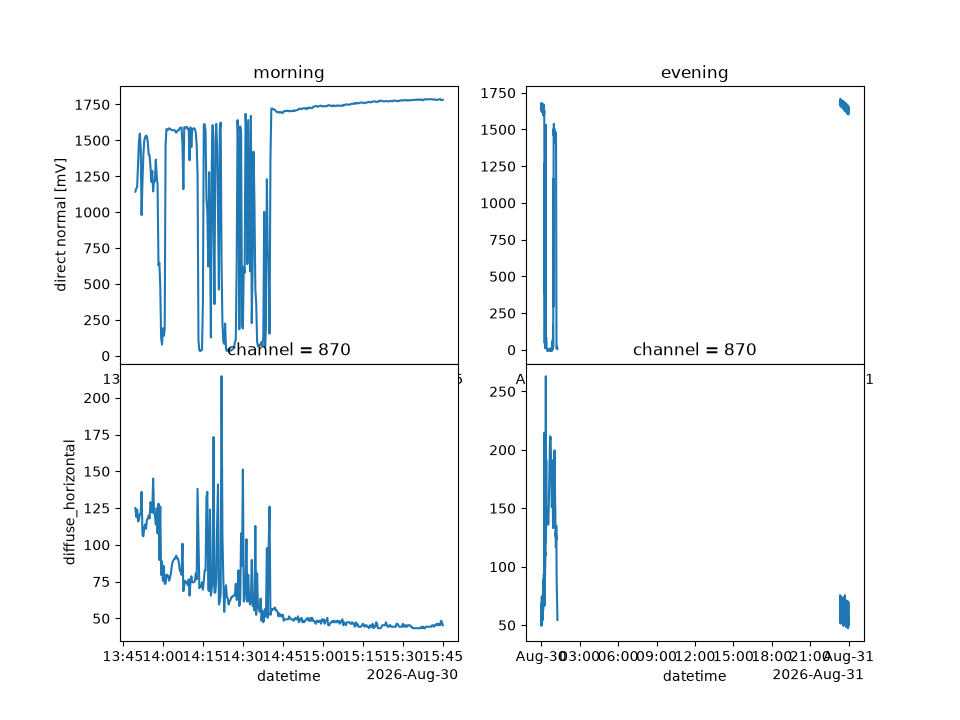

In [27]:
plt.gcf().show()

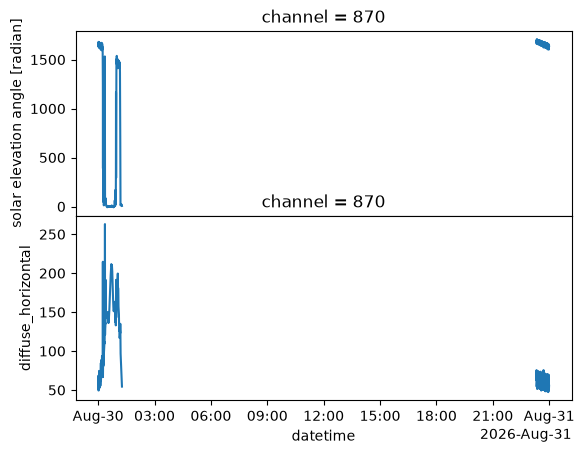

In [23]:
wl = 870
f,aa = plt.subplots(2, sharex=True, gridspec_kw={'hspace':0})
a = aa[0]
# sir.dataset.direct_normal.sel(channel = wl).plot()
ds_pm.direct_normal.sel(channel = wl).plot(ax = a)

a = aa[1]
ds_pm.diffuse_horizontal.sel(channel = wl).plot(ax = a)